# Credit Risk Data Quality Audit

## Project Background

This notebook performs a data quality audit on the Give Me Some Credit dataset.

The target variable is `SeriousDlqin2yrs`:

- `1`: The borrower experienced serious delinquency within two years.
- `0`: The borrower did not experience serious delinquency.

## Audit Objectives

- Understand the dataset structure
- Check missing values
- Examine class imbalance
- Identify duplicated records
- Detect unusual or potentially invalid values
- Prepare the data for credit risk modelling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("/content/cs-training.csv")

df = df.rename(columns={"Unnamed: 0": "customer_id"})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150000, 12)


,customer_id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   customer_id                           150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


In [6]:
target_summary = df["SeriousDlqin2yrs"].value_counts().to_frame("count")
target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

target_summary

,count,percentage
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


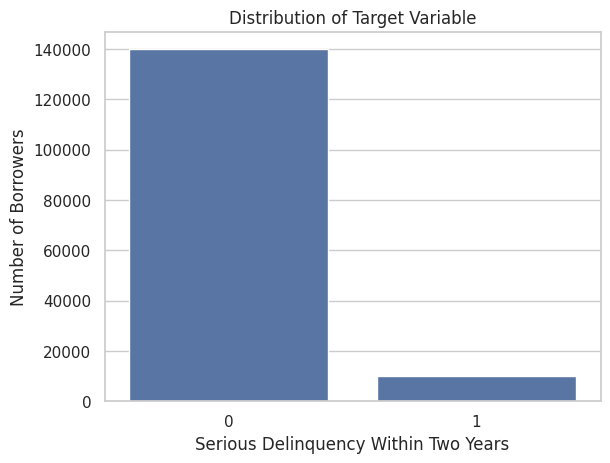

In [7]:
sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Distribution of Target Variable")
plt.xlabel("Serious Delinquency Within Two Years")
plt.ylabel("Number of Borrowers")
plt.show()

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_percentage", ascending=False)

missing_summary

,missing_count,missing_percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


In [9]:
print("Duplicated rows:", df.duplicated().sum())
print("Age equal to 0:", (df["age"] == 0).sum())

print(
    "Utilisation greater than 1:",
    (df["RevolvingUtilizationOfUnsecuredLines"] > 1).sum()
)

print(
    "Debt ratio greater than 1:",
    (df["DebtRatio"] > 1).sum()
)

Duplicated rows: 0
Age equal to 0: 1
Utilisation greater than 1: 3321
Debt ratio greater than 1: 35137


In [10]:
delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    print(f"\n{column}")
    print(df[column].value_counts().sort_index().tail(10))


NumberOfTime30-59DaysPastDueNotWorse
NumberOfTime30-59DaysPastDueNotWorse
6     140
7      54
8      25
9      12
10      4
11      1
12      2
13      1
96      5
98    264
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse
NumberOfTime60-89DaysPastDueNotWorse
3     318
4     105
5      34
6      16
7       9
8       2
9       1
11      1
96      5
98    264
Name: count, dtype: int64

NumberOfTimes90DaysLate
NumberOfTimes90DaysLate
9      19
10      8
11      5
12      2
13      4
14      2
15      2
17      1
96      5
98    264
Name: count, dtype: int64
